# 02 - Exploratory Data Analysis

Notebook này thực hiện **Exploratory Data Analysis (EDA)** trên dữ liệu Telco Customer Churn sau khi dữ liệu đã được kiểm tra và xử lý cơ bản ở notebook 01. EDA là giai đoạn khám phá nhằm hiểu cấu trúc dữ liệu, phát hiện các pattern đáng chú ý, so sánh khách hàng churn và không churn, đồng thời hình thành giả thuyết cho bước xây dựng mô hình.

### Mục tiêu của phase EDA

- Đánh giá phân phối của biến mục tiêu `Churn` và mức độ mất cân bằng lớp.
- Mô tả sự khác biệt về thời gian sử dụng, chi phí và hành vi dịch vụ giữa hai nhóm khách hàng.
- Tính churn rate theo từng nhóm hợp đồng, dịch vụ, thanh toán và đặc điểm cá nhân.
- Kiểm tra quan hệ tuyến tính giữa các biến số và churn bằng correlation.
- Kiểm tra mối liên hệ giữa biến phân loại và churn bằng Chi-square test.
- Khám phá interaction effects giữa nhiều đặc trưng để xác định các phân khúc rủi ro cao.
- Chuyển kết quả thống kê thành insight kinh doanh và định hướng feature cho mô hình classification.

### Phạm vi diễn giải

EDA mô tả các mối liên hệ xuất hiện trong bộ dữ liệu, nhưng không chứng minh quan hệ nhân quả. Ví dụ, churn rate cao ở nhóm dùng `Electronic check` không có nghĩa phương thức này trực tiếp gây churn; nó có thể đồng thời liên quan đến loại hợp đồng, tenure hoặc đặc điểm khách hàng khác. Các kết luận trong notebook cần được xem là bằng chứng mô tả và giả thuyết để kiểm tra thêm.

## 1. Load dữ liệu processed

Dữ liệu đã được làm sạch cơ bản và tách thành hai file ở notebook 01:

- `features.csv`: chứa thông tin cá nhân, dịch vụ, hợp đồng và thanh toán của khách hàng.
- `target.csv`: chứa `customerID` và trạng thái `Churn`.

Trong phase EDA, hai file được merge theo `customerID` để mỗi quan sát có đầy đủ feature và target. Việc merge theo khóa định danh an toàn hơn ghép theo vị trí dòng, vì nó bảo đảm trạng thái churn được gắn đúng khách hàng ngay cả khi thứ tự dữ liệu thay đổi.

Sau khi merge, notebook kiểm tra shape và schema để xác nhận không có khách hàng bị mất hoặc nhân đôi. Biến phụ `ChurnFlag` được tạo theo quy ước `No = 0`, `Yes = 1`. Biến này giúp tính churn rate bằng giá trị trung bình và cho phép đưa churn vào correlation matrix; biến gốc `Churn` vẫn được giữ để trực quan hóa và diễn giải.

In [17]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)

features = pd.read_csv(PROCESSED_DIR / "features.csv")
target = pd.read_csv(PROCESSED_DIR / "target.csv")

df = features.merge(target, on="customerID", how="inner")
df["ChurnFlag"] = df["Churn"].map({"No": 0, "Yes": 1})

print("features:", features.shape)
print("target:", target.shape)
print("merged:", df.shape)
df.head()

features: (7043, 20)
target: (7043, 2)
merged: (7043, 22)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Kiểm tra sau khi merge

Dữ liệu sau khi merge cần giữ nguyên **7,043 khách hàng**. Nếu số dòng tăng, có thể khóa `customerID` bị trùng và tạo many-to-many join; nếu số dòng giảm, có thể một số ID không tồn tại ở cả hai file. Kết quả hiện tại giữ đúng số quan sát nên dữ liệu đủ điều kiện cho EDA.

`ChurnFlag` chỉ là biểu diễn số của target, không phải feature mới. Khi tính trung bình `ChurnFlag` trong một nhóm, kết quả chính là tỷ lệ khách hàng có `Churn = Yes` trong nhóm đó. Ví dụ, trung bình bằng `0.40` tương ứng churn rate 40%.

## 2. Phân tích phân phối target `Churn`

Biến mục tiêu cho biết khách hàng có rời bỏ dịch vụ hay không. Phân tích phân phối target là bước đầu tiên vì tỷ lệ giữa hai lớp ảnh hưởng trực tiếp đến cách đánh giá mô hình và cách diễn giải số lượng khách hàng rủi ro.

Phần này trình bày cả **số lượng tuyệt đối** và **tỷ lệ phần trăm**:

- Số lượng cho biết quy mô thực tế của từng nhóm trong dữ liệu.
- Tỷ lệ giúp so sánh mức độ phổ biến của churn và xác định dữ liệu có mất cân bằng hay không.

Countplot được dùng để quan sát nhanh chênh lệch quy mô hai lớp. Nếu chỉ nhìn Accuracy trong dữ liệu mất cân bằng, mô hình có thể thiên về dự đoán lớp đa số. Vì vậy, kết quả phân phối target sẽ được dùng để lựa chọn metric phù hợp ở phase classification.

,count,percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


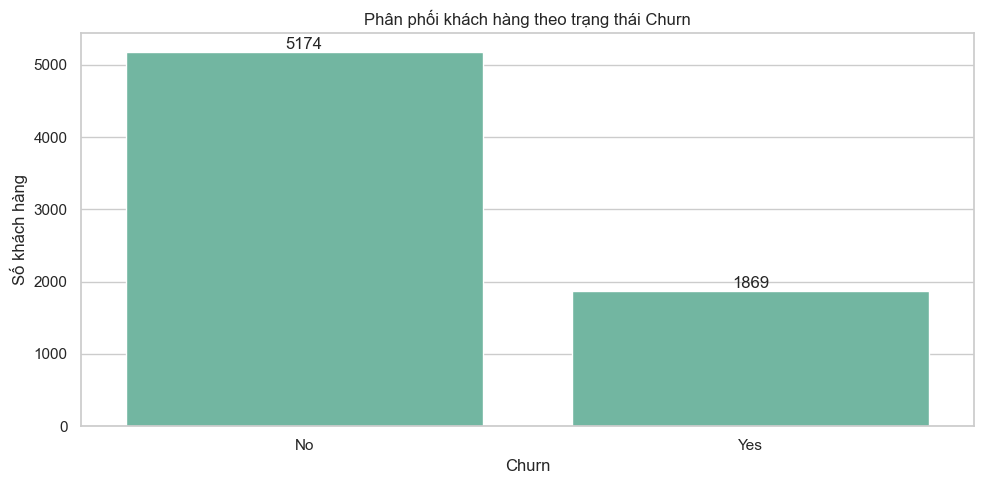

In [19]:
churn_counts = df["Churn"].value_counts()
churn_rate = df["Churn"].value_counts(normalize=True).mul(100).round(2)

target_summary = pd.DataFrame({
    "count": churn_counts,
    "percentage": churn_rate
})
display(target_summary)

ax = sns.countplot(data=df, x="Churn", order=["No", "Yes"])
ax.set_title("Phân phối khách hàng theo trạng thái Churn")
ax.set_xlabel("Churn")
ax.set_ylabel("Số khách hàng")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Insight về biến mục tiêu

Trong 7,043 khách hàng, có **1,869 khách hàng churn** và **5,174 khách hàng không churn**. Tỷ lệ churn là khoảng **26.54%**, trong khi nhóm không churn chiếm **73.46%**. Như vậy, cứ khoảng bốn khách hàng thì có một khách hàng rời bỏ dịch vụ trong phạm vi dữ liệu này.

Dữ liệu mất cân bằng ở mức vừa phải: lớp churn không quá hiếm nhưng vẫn nhỏ hơn đáng kể so với lớp không churn. Một baseline luôn dự đoán `No` đã có thể đạt Accuracy khoảng 73.46% nhưng hoàn toàn không phát hiện được khách churn. Do đó, phase modeling cần báo cáo thêm:

- **Recall của lớp churn:** tỷ lệ khách churn được phát hiện.
- **Precision của lớp churn:** mức chính xác trong nhóm bị cảnh báo.
- **F1-score:** cân bằng Precision và Recall.
- **ROC-AUC/PR-AUC:** khả năng phân biệt và xếp hạng rủi ro trên nhiều threshold.

Về kinh doanh, 26.54% là một nhóm đủ lớn để tạo tác động doanh thu, nhưng cũng đủ nhỏ để doanh nghiệp cần mô hình xếp hạng thay vì áp dụng chương trình giữ chân cho toàn bộ khách hàng.

## 3. Phân tích biến numeric

Ba biến numeric chính phản ánh thời gian gắn bó và giá trị thanh toán của khách hàng:

- `tenure`: số tháng khách hàng đã sử dụng dịch vụ.
- `MonthlyCharges`: chi phí khách hàng phải trả mỗi tháng.
- `TotalCharges`: tổng chi phí tích lũy trong toàn bộ thời gian sử dụng.

Phần này sử dụng ba góc nhìn bổ sung cho nhau:

1. **Bảng thống kê mô tả:** so sánh count, mean, median, standard deviation, min và max giữa hai nhóm.
2. **Boxplot:** quan sát trung vị, độ phân tán, độ lệch và các giá trị ngoại lệ giữa nhóm churn và không churn.
3. **Histogram kết hợp KDE:** quan sát toàn bộ hình dạng phân phối và vùng chồng lấn giữa hai nhóm.

Mean và median được xem cùng nhau vì các biến chi phí thường có phân phối lệch. Nếu mean lớn hơn median đáng kể, một số khách hàng có giá trị cao đang kéo trung bình lên.

In [20]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

numeric_summary = df.groupby("Churn")[numeric_cols].agg(["count", "mean", "median", "std", "min", "max"]).round(2)
display(numeric_summary)

numeric_summary.to_csv(REPORTS_DIR / "numeric_summary_by_churn.csv")

tenure                              MonthlyCharges                       \
       count   mean median    std min max          count   mean median    std   
Churn                                                                           
No      5174  37.57   38.0  24.11   0  72           5174  61.27  64.43  31.09   
Yes     1869  17.98   10.0  19.53   1  72           1869  74.44  79.65  24.67   

                     TotalCharges                                             
         min     max        count     mean   median      std    min      max  
Churn                                                                         
No     18.25  118.75         5174  2549.91  1679.52  2329.95   0.00  8672.45  
Yes    18.85  118.35         1869  1531.80   703.55  1890.82  18.85  8684.80

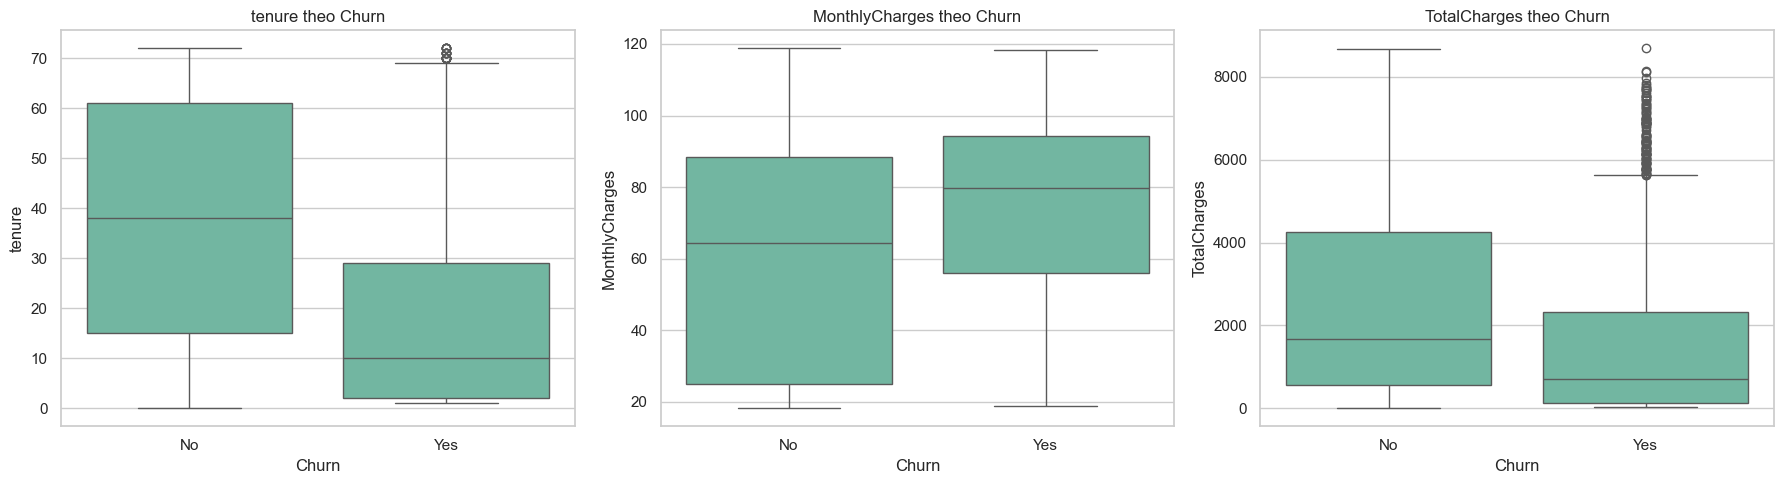

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x="Churn", y=col, order=["No", "Yes"], ax=ax)
    ax.set_title(f"{col} theo Churn")
    ax.set_xlabel("Churn")

plt.tight_layout()
plt.show()

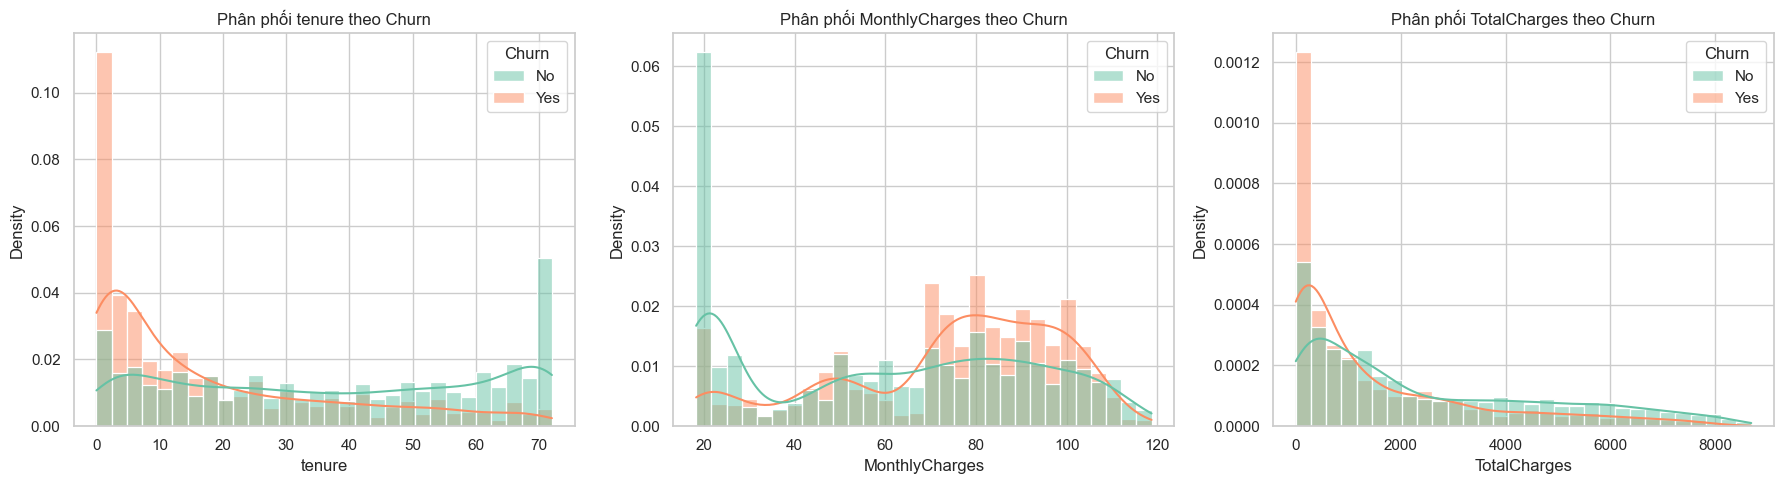

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, numeric_cols):
    sns.histplot(data=df, x=col, hue="Churn", bins=30, kde=True, stat="density", common_norm=False, ax=ax)
    ax.set_title(f"Phân phối {col} theo Churn")

plt.tight_layout()
plt.show()

### Insight từ biến numeric

**`tenure`:** nhóm không churn có tenure trung bình khoảng **37.57 tháng** và trung vị **38 tháng**, trong khi nhóm churn chỉ có trung bình **17.98 tháng** và trung vị **10 tháng**. Chênh lệch lớn cho thấy rủi ro churn tập trung nhiều ở giai đoạn đầu của vòng đời khách hàng. Đây là cơ sở để doanh nghiệp ưu tiên onboarding, chăm sóc sớm và theo dõi khách mới.

**`MonthlyCharges`:** nhóm churn trả trung bình khoảng **74.44** mỗi tháng, cao hơn nhóm không churn với khoảng **61.27**. Trung vị tương ứng là **79.65** và **64.43**. Điều này cho thấy chi phí định kỳ cao có liên hệ với churn, có thể do cảm nhận giá trị chưa tương xứng, gói dịch vụ đắt hoặc nhóm dịch vụ như Fiber optic có mức phí cao hơn.

**`TotalCharges`:** nhóm churn có tổng chi trả trung bình khoảng **1,531.80**, thấp hơn nhóm không churn khoảng **2,549.91**. Không nên kết luận rằng chi tiêu thấp gây churn, bởi `TotalCharges` phụ thuộc mạnh vào `tenure`. Khách churn rời đi sớm nên chưa có đủ thời gian tích lũy tổng phí, ngay cả khi `MonthlyCharges` của họ cao.

### Hàm ý phân tích

Các phân phối vẫn chồng lấn đáng kể, nghĩa là không biến numeric nào có thể tự phân loại churn hoàn hảo. Mô hình cần kết hợp thời gian sử dụng, chi phí và các đặc trưng hợp đồng/dịch vụ. Ngoài ra, mối quan hệ giữa `tenure` và `TotalCharges` có thể gây multicollinearity trong mô hình tuyến tính, nên coefficient cần được diễn giải thận trọng.

## 4. Phân tích biến categorical

Biến categorical mô tả loại hợp đồng, dịch vụ đang sử dụng, phương thức thanh toán và một số đặc điểm cá nhân. Đây là nhóm feature quan trọng vì churn thường không chỉ phụ thuộc vào mức phí mà còn liên quan đến mức cam kết, trải nghiệm dịch vụ và mức độ gắn kết.

Các biến được tập trung phân tích gồm:

- `Contract`: mức độ cam kết theo tháng, một năm hoặc hai năm.
- `InternetService`: loại dịch vụ Internet khách hàng sử dụng.
- `OnlineSecurity`, `TechSupport`: các dịch vụ hỗ trợ và bảo vệ bổ sung.
- `PaymentMethod`, `PaperlessBilling`: hành vi thanh toán và nhận hóa đơn.
- `Dependents`, `Partner`: bối cảnh cá nhân và gia đình.

Hai loại biểu đồ được sử dụng:

- **Countplot:** cho biết quy mô mẫu của mỗi category và số khách churn/không churn.
- **Barplot churn rate:** chuẩn hóa theo quy mô từng category, cho phép so sánh xác suất churn công bằng hơn.

Churn rate cần được đọc cùng `count`. Một nhóm có tỷ lệ rất cao nhưng chỉ vài quan sát sẽ kém ổn định hơn một nhóm lớn. Trong dữ liệu này, các nhóm nổi bật đều có quy mô đủ lớn để đáng quan tâm.

In [23]:
categorical_cols = [
    "Contract",
    "InternetService",
    "OnlineSecurity",
    "TechSupport",
    "PaymentMethod",
    "PaperlessBilling",
    "Dependents",
    "Partner",
]

def churn_rate_table(data: pd.DataFrame, column: str) -> pd.DataFrame:
    table = (
        data.groupby(column)["ChurnFlag"]
        .agg(count="count", churn_rate="mean")
        .assign(churn_rate_pct=lambda x: (x["churn_rate"] * 100).round(2))
        .drop(columns="churn_rate")
        .sort_values("churn_rate_pct", ascending=False)
    )
    return table

all_churn_rate_tables = []

for col in categorical_cols:
    table = churn_rate_table(df, col)
    display(pd.DataFrame({"feature": col}, index=table.index).join(table))
    all_churn_rate_tables.append(table.assign(feature=col).reset_index().rename(columns={col: "category"}))

categorical_churn_rates = pd.concat(all_churn_rate_tables, ignore_index=True)
categorical_churn_rates.to_csv(REPORTS_DIR / "categorical_churn_rates.csv", index=False)

,feature,count,churn_rate_pct
Contract,,,
Month-to-month,Contract,3875,42.71
One year,Contract,1473,11.27
Two year,Contract,1695,2.83


,feature,count,churn_rate_pct
InternetService,,,
Fiber optic,InternetService,3096,41.89
DSL,InternetService,2421,18.96
No,InternetService,1526,7.40


,feature,count,churn_rate_pct
OnlineSecurity,,,
No,OnlineSecurity,3498,41.77
Yes,OnlineSecurity,2019,14.61
No internet service,OnlineSecurity,1526,7.40


,feature,count,churn_rate_pct
TechSupport,,,
No,TechSupport,3473,41.64
Yes,TechSupport,2044,15.17
No internet service,TechSupport,1526,7.40


,feature,count,churn_rate_pct
PaymentMethod,,,
Electronic check,PaymentMethod,2365,45.29
Mailed check,PaymentMethod,1612,19.11
Bank transfer (automatic),PaymentMethod,1544,16.71
Credit card (automatic),PaymentMethod,1522,15.24


,feature,count,churn_rate_pct
PaperlessBilling,,,
Yes,PaperlessBilling,4171,33.57
No,PaperlessBilling,2872,16.33


,feature,count,churn_rate_pct
Dependents,,,
No,Dependents,4933,31.28
Yes,Dependents,2110,15.45


,feature,count,churn_rate_pct
Partner,,,
No,Partner,3641,32.96
Yes,Partner,3402,19.66


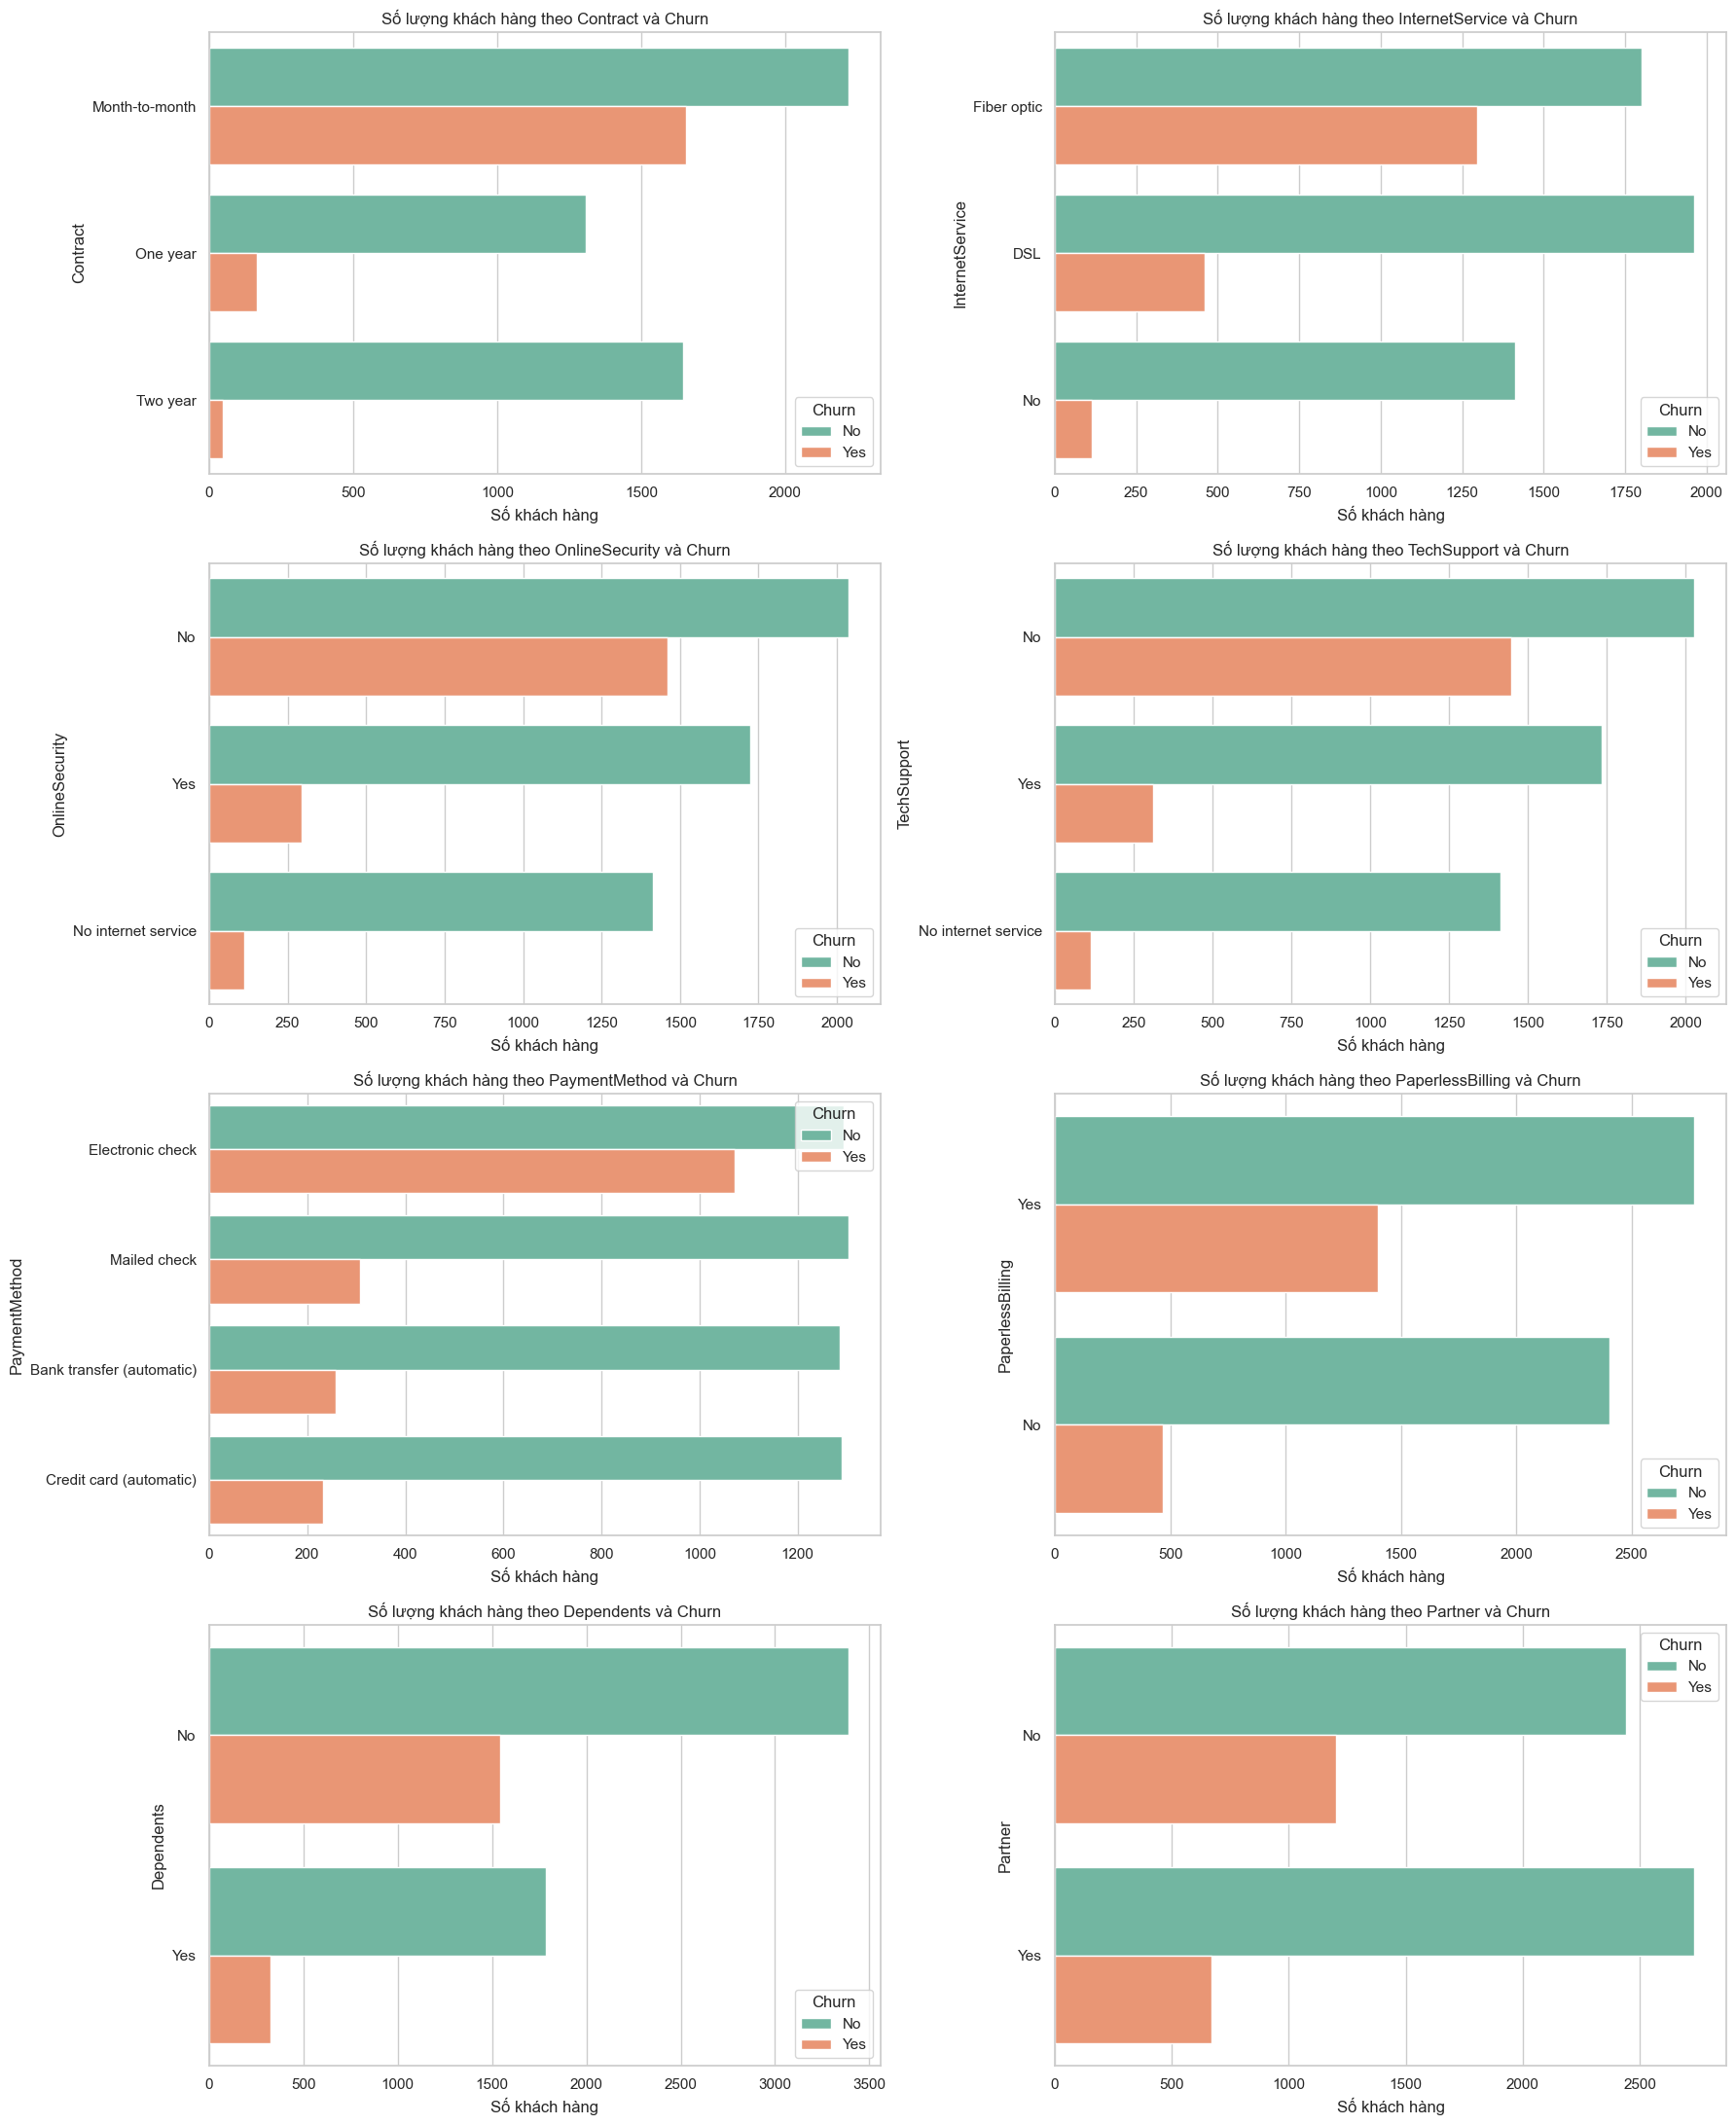

In [24]:
fig, axes = plt.subplots(4, 2, figsize=(18, 22))
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    order = churn_rate_table(df, col).index.tolist()
    sns.countplot(data=df, y=col, hue="Churn", order=order, ax=ax)
    ax.set_title(f"Số lượng khách hàng theo {col} và Churn")
    ax.set_xlabel("Số khách hàng")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

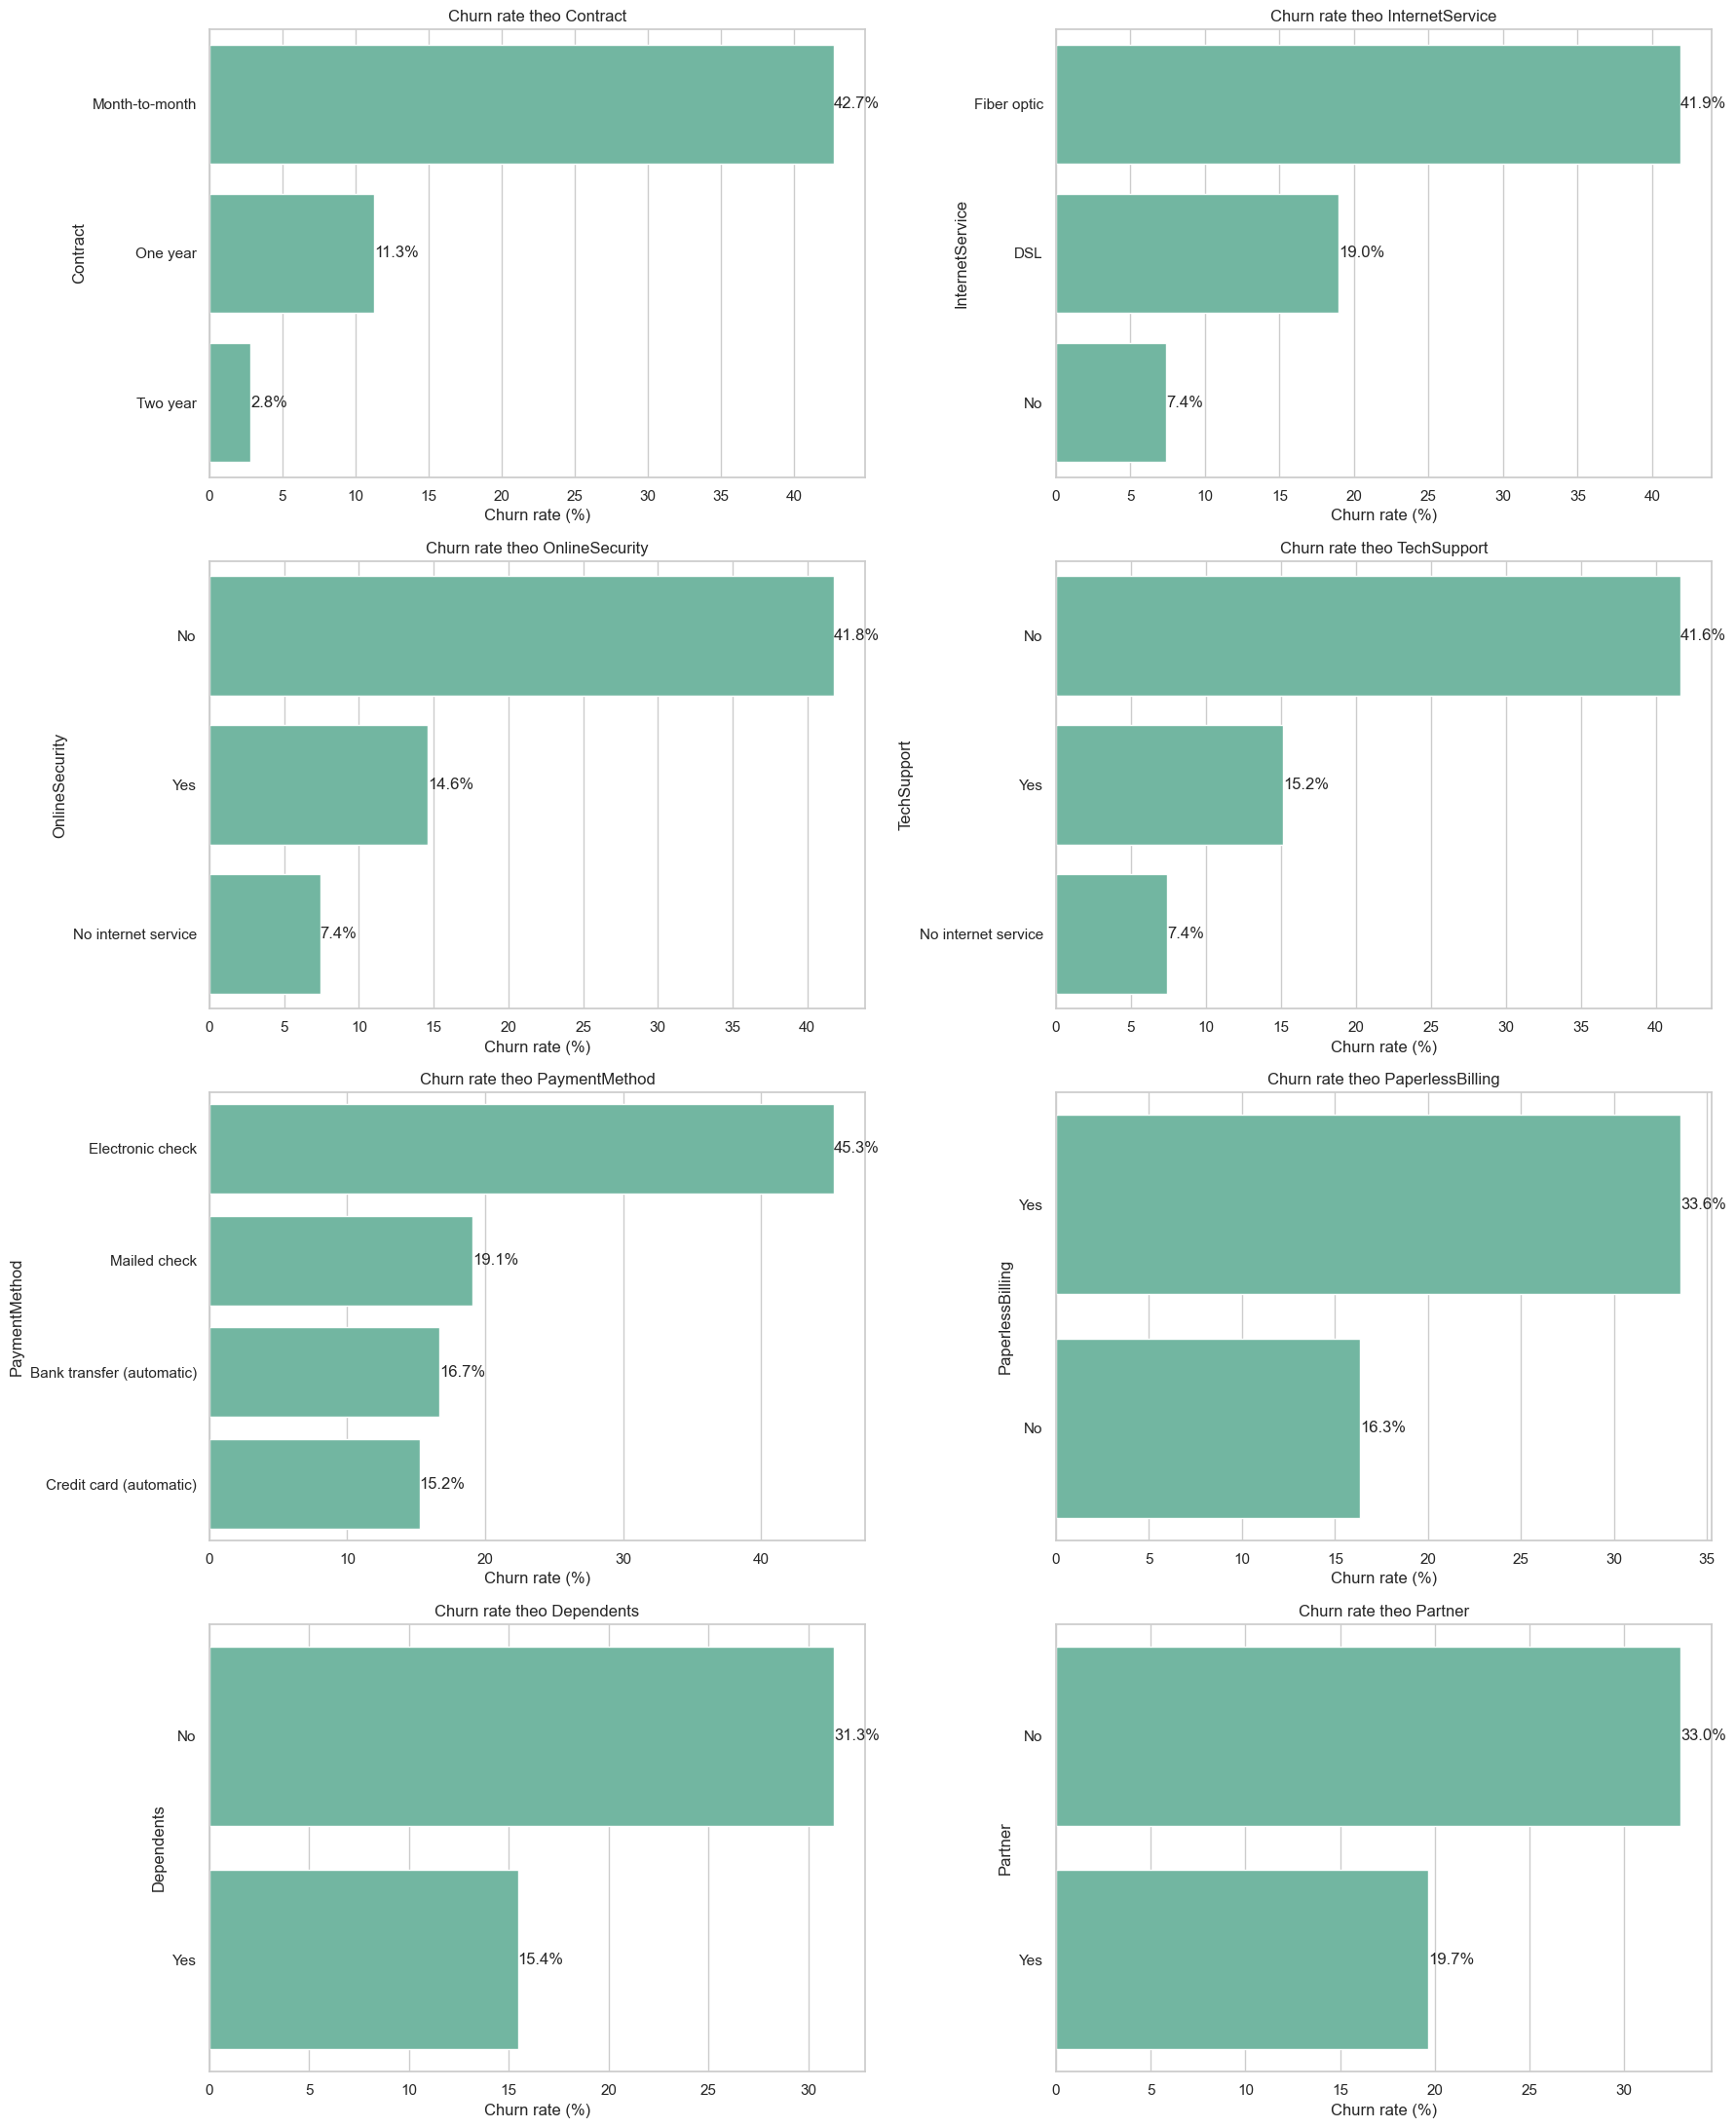

In [25]:
fig, axes = plt.subplots(4, 2, figsize=(18, 22))
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    table = churn_rate_table(df, col).reset_index()
    sns.barplot(data=table, y=col, x="churn_rate_pct", ax=ax)
    ax.set_title(f"Churn rate theo {col}")
    ax.set_xlabel("Churn rate (%)")
    ax.set_ylabel(col)
    ax.bar_label(ax.containers[0], fmt="%.1f%%")

plt.tight_layout()
plt.show()

### Insight từ biến categorical

**Hợp đồng:** khách hàng `Month-to-month` có churn rate **42.71%**, cao hơn rõ rệt so với `One year` (**11.27%**) và `Two year` (**2.83%**). Hợp đồng dài hạn có thể phản ánh mức cam kết cao hơn, chi phí chuyển đổi lớn hơn hoặc các ưu đãi tốt hơn. Đây là tín hiệu phân biệt churn mạnh nhất trong EDA.

**Dịch vụ Internet:** nhóm `Fiber optic` có churn rate **41.89%**, so với `DSL` **18.96%** và nhóm không dùng Internet **7.40%**. Kết quả này cần được phân tích cùng `MonthlyCharges`, chất lượng dịch vụ và hợp đồng; không nên kết luận riêng rằng Fiber optic gây churn.

**Dịch vụ hỗ trợ:** khách không có `OnlineSecurity` và không có `TechSupport` có churn rate lần lượt **41.77%** và **41.64%**. Khi có các dịch vụ này, churn rate giảm xuống khoảng 14-15%. Các dịch vụ bổ sung có thể làm tăng mức gắn kết, nhưng cũng có thể đại diện cho nhóm khách hàng mua gói đầy đủ hoặc có hợp đồng dài hơn.

**Thanh toán:** `Electronic check` có churn rate cao nhất, khoảng **45.29%**. Các phương thức tự động có churn rate thấp hơn: bank transfer **16.71%** và credit card **15.24%**. Đây có thể là tín hiệu về mức cam kết thanh toán, trải nghiệm thanh toán hoặc đặc điểm của nhóm khách dùng hợp đồng tháng.

**Paperless billing và đặc điểm cá nhân:** nhóm dùng `PaperlessBilling` có churn rate **33.57%**, cao hơn nhóm không dùng (**16.33%**). Khách không có `Dependents` hoặc không có `Partner` cũng có tỷ lệ churn cao hơn. Tuy nhiên, các yếu tố này có thể liên quan gián tiếp qua tuổi, tenure, loại hợp đồng hoặc hành vi số.

### Hàm ý kinh doanh

Một phân khúc ưu tiên ban đầu là khách hàng hợp đồng tháng, dùng Fiber optic, không có dịch vụ hỗ trợ và thanh toán Electronic check. Doanh nghiệp có thể thử chương trình chuyển sang hợp đồng dài hạn, rà soát trải nghiệm Fiber optic, cung cấp gói hỗ trợ dùng thử hoặc khuyến khích thanh toán tự động. Hiệu quả cần được xác nhận bằng thử nghiệm A/B thay vì chỉ dựa vào EDA.

## 5. Correlation cho biến số

Correlation matrix được dùng để đo chiều và mức độ liên hệ tuyến tính giữa các biến numeric và `ChurnFlag`:

- Hệ số gần `+1`: hai biến có xu hướng tăng cùng nhau.
- Hệ số gần `-1`: một biến tăng khi biến còn lại giảm.
- Hệ số gần `0`: không có quan hệ tuyến tính rõ ràng.

Vì `ChurnFlag` là biến nhị phân 0/1, correlation với một biến số tương đương point-biserial correlation. Heatmap giúp quan sát nhanh chiều quan hệ và phát hiện các feature số có tương quan mạnh với nhau.

Correlation chỉ đo quan hệ tuyến tính và không phản ánh tốt các quan hệ phi tuyến hoặc interaction. Hệ số thấp không đồng nghĩa feature không hữu ích cho mô hình.

,tenure,MonthlyCharges,TotalCharges,ChurnFlag
tenure,1.000,0.248,0.826,-0.352
MonthlyCharges,0.248,1.000,0.651,0.193
TotalCharges,0.826,0.651,1.000,-0.198
ChurnFlag,-0.352,0.193,-0.198,1.000


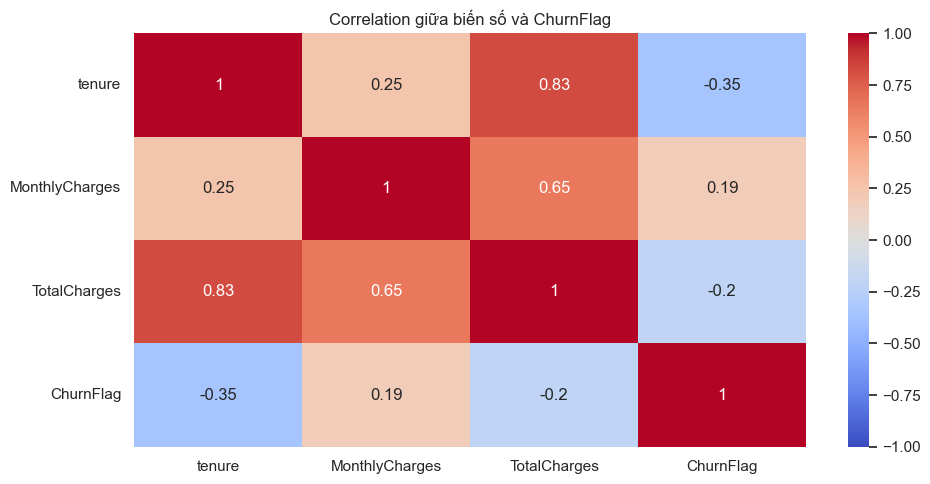

In [26]:
corr_cols = numeric_cols + ["ChurnFlag"]
corr_matrix = df[corr_cols].corr().round(3)
display(corr_matrix)

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation giữa biến số và ChurnFlag")
plt.tight_layout()
plt.show()

### Insight từ correlation

`tenure` có tương quan âm với `ChurnFlag`, phù hợp với kết quả boxplot: khách hàng gắn bó lâu hơn có xu hướng churn thấp hơn. `MonthlyCharges` có tương quan dương, cho thấy mức phí hàng tháng cao thường đi cùng xác suất churn cao hơn.

`TotalCharges` cần được diễn giải cẩn thận vì đây gần như là kết quả tích lũy của `tenure` và `MonthlyCharges`. Biến này có thể tương quan mạnh với tenure nhưng vẫn có quan hệ âm với churn do khách churn thường rời đi sớm. Đây là ví dụ cho thấy correlation không tách được tác động riêng của từng biến.

Trong phase modeling, các biến tương quan vẫn có thể được giữ lại vì regularization của Logistic Regression và cấu trúc cây của Random Forest có khả năng xử lý ở mức nhất định. Tuy nhiên, coefficient không nên được diễn giải như tác động độc lập tuyệt đối.

## 6. Chi-square test cho biến phân loại

Chi-square test of independence được sử dụng để kiểm tra liệu phân phối `Churn` có khác nhau giữa các category hay không.

- **Giả thuyết H0:** biến phân loại và `Churn` độc lập; tỷ lệ churn không khác đáng kể giữa các nhóm.
- **Giả thuyết H1:** hai biến có liên hệ; ít nhất một nhóm có phân phối churn khác kỳ vọng.
- **Mức ý nghĩa:** `alpha = 0.05`. Nếu `p_value < 0.05`, bác bỏ H0.

Kiểm định được thực hiện trên contingency table tạo bởi `pd.crosstab`. Các giả định chính gồm quan sát độc lập và expected frequency đủ lớn trong phần lớn ô. Bộ dữ liệu có quy mô lớn và các category được phân tích đều có nhiều quan sát nên điều kiện này nhìn chung phù hợp.

Chi-square cho biết có mối liên hệ thống kê hay không, nhưng không cho biết chiều, độ lớn thực tế hoặc quan hệ nhân quả. Vì vậy, kết quả phải được đọc cùng churn rate và quy mô từng nhóm.

In [27]:
chi_square_results = []

for col in categorical_cols:
    contingency = pd.crosstab(df[col], df["Churn"])
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    chi_square_results.append({
        "feature": col,
        "chi2": chi2,
        "p_value": p_value,
        "dof": dof,
        "significant_at_0.05": p_value < 0.05,
    })

chi_square_df = pd.DataFrame(chi_square_results).sort_values("p_value")
chi_square_df[["chi2", "p_value"]] = chi_square_df[["chi2", "p_value"]].round(6)
display(chi_square_df)

chi_square_df.to_csv(REPORTS_DIR / "chi_square_tests.csv", index=False)

,feature,chi2,p_value,dof,significant_at_0.05
0,Contract,1184.596572,0.0,2,True
2,OnlineSecurity,849.998968,0.0,2,True
3,TechSupport,828.197068,0.0,2,True
1,InternetService,732.309590,0.0,2,True
4,PaymentMethod,648.142327,0.0,3,True
5,PaperlessBilling,258.277649,0.0,1,True
6,Dependents,189.129249,0.0,1,True
7,Partner,158.733382,0.0,1,True


### Insight từ Chi-square test

Tất cả tám biến được kiểm tra đều có `p_value < 0.05`, do đó có bằng chứng thống kê rằng chúng liên hệ với `Churn`. Những biến có Chi-square statistic lớn nhất gồm:

- `Contract`: khoảng **1184.60**
- `OnlineSecurity`: khoảng **850.00**
- `TechSupport`: khoảng **828.20**
- `InternetService`: khoảng **732.31**
- `PaymentMethod`: khoảng **648.14**

Thứ tự này nhất quán với churn-rate analysis: loại hợp đồng, dịch vụ hỗ trợ, loại Internet và phương thức thanh toán tạo ra chênh lệch lớn giữa các nhóm. Tuy nhiên, Chi-square statistic còn phụ thuộc kích thước mẫu và số category, nên không nên xem nó là thước đo feature importance trực tiếp.

Do kích thước mẫu lớn, ngay cả khác biệt nhỏ cũng có thể đạt ý nghĩa thống kê. Ý nghĩa thực tế cần dựa thêm vào mức chênh churn rate, số khách hàng bị ảnh hưởng và khả năng can thiệp của doanh nghiệp.

## 7. Interaction effects

Phân tích từng feature riêng lẻ có thể bỏ sót trường hợp nhiều đặc trưng cùng xuất hiện và tạo thành một phân khúc rủi ro đặc biệt. **Interaction effect** xảy ra khi mối liên hệ giữa một feature và churn thay đổi tùy theo giá trị của feature khác.

Notebook sử dụng pivot table và heatmap để khám phá ba tổ hợp:

1. `Contract × InternetService`: kiểm tra rủi ro của từng loại Internet trong các mức cam kết hợp đồng.
2. `Contract × PaymentMethod`: kiểm tra liệu phương thức thanh toán có đặc biệt rủi ro ở nhóm hợp đồng tháng hay không.
3. `tenure_group × Contract`: kiểm tra tác động kết hợp giữa vòng đời khách hàng và mức cam kết.

Mỗi ô heatmap là churn rate của một phân khúc kết hợp. Màu đậm biểu thị tỷ lệ churn cao hơn. Khi đọc heatmap, cần chú ý cả quy mô từng ô; một tỷ lệ cao ở nhóm rất nhỏ có thể không ổn định.

Đây là phân tích mô tả interaction. Để kiểm định chính thức, có thể bổ sung interaction terms trong Logistic Regression hoặc sử dụng mô hình cây và các công cụ giải thích như partial dependence/SHAP.

InternetService,DSL,Fiber optic,No
Contract,,,
Month-to-month,32.22,54.61,18.89
One year,9.30,19.29,2.47
Two year,1.91,7.23,0.78


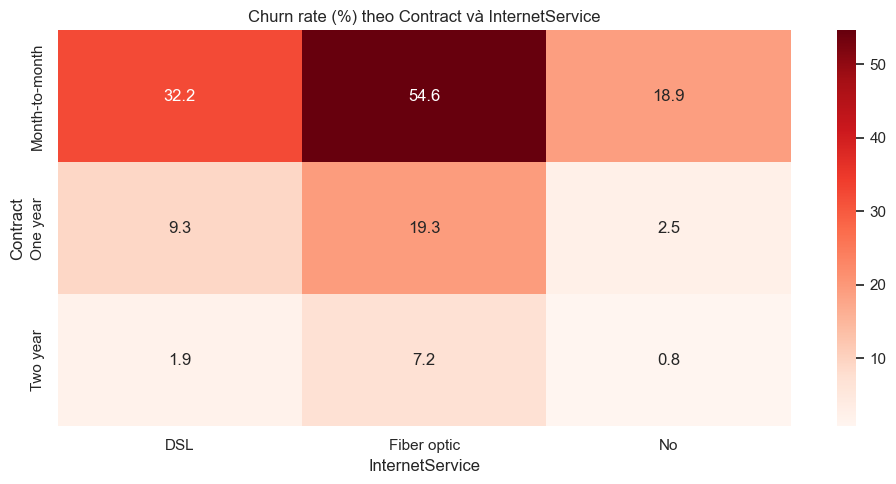

In [28]:
contract_internet = pd.pivot_table(
    df,
    values="ChurnFlag",
    index="Contract",
    columns="InternetService",
    aggfunc="mean",
).mul(100).round(2)

display(contract_internet)

sns.heatmap(contract_internet, annot=True, fmt=".1f", cmap="Reds")
plt.title("Churn rate (%) theo Contract và InternetService")
plt.xlabel("InternetService")
plt.ylabel("Contract")
plt.tight_layout()
plt.show()

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Contract,,,,
Month-to-month,34.13,32.78,53.73,31.58
One year,9.72,10.30,18.44,6.82
Two year,3.37,2.24,7.74,0.79


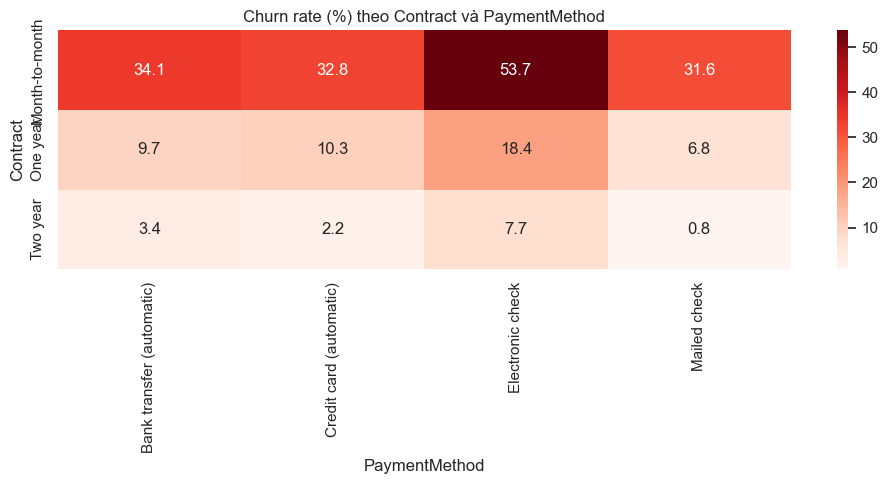

In [29]:
contract_payment = pd.pivot_table(
    df,
    values="ChurnFlag",
    index="Contract",
    columns="PaymentMethod",
    aggfunc="mean",
).mul(100).round(2)

display(contract_payment)

sns.heatmap(contract_payment, annot=True, fmt=".1f", cmap="Reds")
plt.title("Churn rate (%) theo Contract và PaymentMethod")
plt.xlabel("PaymentMethod")
plt.ylabel("Contract")
plt.tight_layout()
plt.show()

Contract,Month-to-month,One year,Two year
tenure_group,,,
0-6,55.20,10.26,0.00
7-12,42.00,10.59,0.00
13-24,37.72,8.12,0.00
25-48,32.92,10.62,2.19
49-72,26.02,12.93,3.33


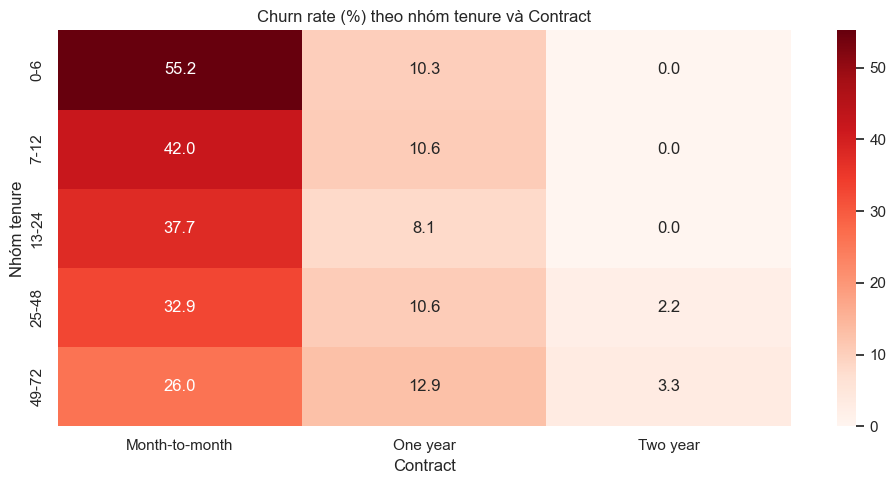

In [30]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=["0-6", "7-12", "13-24", "25-48", "49-72"],
)

tenure_contract = pd.pivot_table(
    df,
    values="ChurnFlag",
    index="tenure_group",
    columns="Contract",
    aggfunc="mean",
    observed=False,
).mul(100).round(2)

display(tenure_contract)

sns.heatmap(tenure_contract, annot=True, fmt=".1f", cmap="Reds")
plt.title("Churn rate (%) theo nhóm tenure và Contract")
plt.xlabel("Contract")
plt.ylabel("Nhóm tenure")
plt.tight_layout()
plt.show()

### Insight từ interaction effects

Các heatmap cho thấy rủi ro churn không phân bố đồng đều trong từng feature. Nhóm `Month-to-month` thường giữ mức churn cao hơn ở nhiều loại Internet và phương thức thanh toán. Khi kết hợp thêm `Electronic check`, Fiber optic hoặc tenure thấp, mức rủi ro tiếp tục nổi bật.

Tổ hợp `tenure thấp × Month-to-month` đặc biệt quan trọng: đây là nhóm khách hàng mới, chưa có cam kết dài hạn và có thể rời bỏ với chi phí chuyển đổi thấp. Doanh nghiệp nên can thiệp sớm trong 6-12 tháng đầu thay vì chờ đến khi khách hàng đã thể hiện dấu hiệu rời bỏ rõ ràng.

Về triển khai, interaction giúp xây dựng rule-based segment dễ hiểu song song với model ML. Ví dụ, có thể tạo danh sách ưu tiên gồm khách hợp đồng tháng, tenure dưới 12 tháng, dùng Fiber optic và thanh toán Electronic check. Model classification sau đó sẽ cung cấp xác suất chi tiết hơn để xếp hạng trong phân khúc này.

## 8. Tóm tắt khám phá dữ liệu (EDA Summary)

Sau quá trình phân tích khám phá dữ liệu, có thể tổng hợp các phát hiện chính như sau:

### 8.1. Tổng quan về biến mục tiêu

Bộ dữ liệu có 7,043 khách hàng, trong đó 5,174 khách hàng không rời bỏ dịch vụ và 1,869 khách hàng rời bỏ dịch vụ. Tỷ lệ churn chiếm khoảng 26.54%, còn nhóm không churn chiếm khoảng 73.46%. Điều này cho thấy dữ liệu có mất cân bằng lớp ở mức vừa phải. Vì vậy, trong giai đoạn xây dựng mô hình, Accuracy không nên là thước đo duy nhất; cần ưu tiên thêm Recall và F1-score cho nhóm `Churn = Yes` để giảm rủi ro bỏ sót khách hàng có khả năng rời bỏ.

### 8.2. Khác biệt ở các biến numeric

Ba biến số quan trọng trong dữ liệu là `tenure`, `MonthlyCharges` và `TotalCharges`. Nhóm khách hàng churn có `tenure` trung bình thấp hơn rõ rệt so với nhóm không churn, cho thấy khách hàng mới hoặc khách hàng chưa gắn bó lâu có nguy cơ rời bỏ cao hơn. Ngược lại, `MonthlyCharges` của nhóm churn cao hơn nhóm không churn, gợi ý rằng chi phí hàng tháng cao có thể tạo áp lực khiến khách hàng cân nhắc hủy dịch vụ. `TotalCharges` của nhóm churn thấp hơn chủ yếu vì họ rời bỏ sớm, nên tổng chi phí tích lũy chưa cao dù chi phí hàng tháng có thể cao.

### 8.3. Các nhóm khách hàng có churn rate cao

Phân tích các biến phân loại cho thấy một số nhóm có churn rate nổi bật. Khách hàng dùng hợp đồng `Month-to-month` có churn rate khoảng 42.71%, cao hơn rất nhiều so với hợp đồng `One year` và `Two year`. Nhóm dùng `Fiber optic` có churn rate khoảng 41.89%, cao hơn nhóm dùng `DSL` và nhóm không dùng Internet. Ngoài ra, khách hàng không có `OnlineSecurity` hoặc không có `TechSupport` cũng có churn rate trên 41%, cho thấy các dịch vụ hỗ trợ và bảo vệ có thể liên quan đến mức độ gắn kết của khách hàng.

### 8.4. Ảnh hưởng của thanh toán và thông tin cá nhân

Phương thức thanh toán có khác biệt đáng kể giữa các nhóm khách hàng. Nhóm thanh toán bằng `Electronic check` có churn rate khoảng 45.29%, cao hơn các phương thức thanh toán tự động như bank transfer hoặc credit card. Khách hàng dùng `PaperlessBilling` cũng có churn rate cao hơn nhóm không dùng hóa đơn điện tử. Với thông tin cá nhân, nhóm không có `Dependents` và nhóm không có `Partner` có churn rate cao hơn, gợi ý rằng khách hàng ít ràng buộc gia đình hoặc cá nhân hơn có thể linh hoạt hơn trong quyết định rời bỏ dịch vụ.

### 8.5. Kết quả correlation và Chi-square test

Correlation cho thấy `tenure` có xu hướng tương quan âm với churn, tức khách hàng sử dụng dịch vụ càng lâu thì xác suất churn càng thấp. `MonthlyCharges` có xu hướng tương quan dương với churn, nghĩa là chi phí hàng tháng cao hơn thường đi kèm rủi ro churn cao hơn. Với các biến phân loại, Chi-square test cho thấy nhiều đặc trưng như `Contract`, `InternetService`, `OnlineSecurity`, `TechSupport`, `PaymentMethod`, `PaperlessBilling`, `Dependents` và `Partner` có liên hệ thống kê với `Churn`. Điều này củng cố nhận định rằng churn không phải hiện tượng ngẫu nhiên mà có quan hệ rõ với đặc điểm hợp đồng, dịch vụ và hành vi thanh toán.

### 8.6. Interaction effects đáng chú ý

Các heatmap interaction cho thấy rủi ro churn tăng mạnh khi nhiều yếu tố bất lợi xuất hiện cùng lúc. Đặc biệt, nhóm khách hàng có hợp đồng `Month-to-month`, tenure thấp, dùng `Fiber optic` hoặc thanh toán bằng `Electronic check` là nhóm có tín hiệu rủi ro cao. Điều này quan trọng về mặt kinh doanh vì doanh nghiệp có thể ưu tiên nhóm này trong các chiến dịch giữ chân, thay vì triển khai ưu đãi đại trà cho toàn bộ khách hàng.

### 8.7. Hàm ý cho bước xây dựng mô hình

Từ EDA, các biến liên quan đến hợp đồng, thời gian sử dụng, chi phí hàng tháng, dịch vụ Internet, dịch vụ hỗ trợ và phương thức thanh toán nên được giữ lại trong mô hình classification. Không nên loại feature chỉ vì correlation riêng lẻ thấp, bởi biến categorical và interaction vẫn có thể mang thông tin dự đoán quan trọng.

Vì bài toán hướng đến phát hiện khách hàng có nguy cơ churn, mô hình ở phase tiếp theo cần được đánh giá bằng Recall, Precision, F1-score và ROC-AUC thay vì chỉ dựa vào Accuracy. Preprocessing cần được đặt trong pipeline để imputation, scaling và encoding chỉ học từ tập train. Sau khi huấn luyện, threshold phải được tối ưu để cân bằng giữa phát hiện nhiều khách churn và tránh flag quá nhiều khách hàng không churn.

### 8.8. Chân dung phân khúc rủi ro cao

Tổng hợp các phát hiện cho thấy chân dung khách hàng rủi ro cao thường có nhiều đặc điểm đồng thời: tenure thấp, hợp đồng `Month-to-month`, MonthlyCharges cao, dùng Fiber optic, không có OnlineSecurity/TechSupport và thanh toán bằng Electronic check. Đây là một **risk profile**, không phải quy tắc tuyệt đối. Không phải mọi khách hàng có các đặc điểm trên đều churn và một số khách churn có thể không thuộc phân khúc này.

Về kinh doanh, risk profile giúp xác định đối tượng cho chiến dịch thử nghiệm ban đầu. Về kỹ thuật, mô hình classification sẽ kết hợp toàn bộ feature để tạo xác suất churn ở cấp khách hàng, chính xác và linh hoạt hơn rule-based segmentation.


## 9. Trả lời câu hỏi nghiên cứu

### a. Yếu tố nào liên quan đến khả năng rời bỏ?

Các yếu tố nổi bật nhất gồm `Contract`, `tenure`, `MonthlyCharges`, `InternetService`, `OnlineSecurity`, `TechSupport` và `PaymentMethod`. `Contract` tạo khác biệt lớn nhất: churn rate của hợp đồng tháng là 42.71%, trong khi hợp đồng hai năm chỉ 2.83%. Nhóm churn cũng có tenure trung bình thấp hơn khoảng 19.6 tháng và MonthlyCharges trung bình cao hơn khoảng 13.2 đơn vị so với nhóm không churn.

Chi-square test xác nhận các biến categorical được phân tích đều có liên hệ thống kê với churn. Tuy nhiên, từ “ảnh hưởng” ở đây được hiểu là **liên hệ dự đoán**, không phải nguyên nhân trực tiếp. Cần kiểm soát các biến khác hoặc thực hiện thí nghiệm mới có thể kết luận nhân quả.

### b. Điểm nào phân biệt khách hàng rời bỏ và không rời bỏ?

Khách hàng churn thường mới sử dụng dịch vụ, trả phí hàng tháng cao, dùng hợp đồng linh hoạt theo tháng và ít có các dịch vụ hỗ trợ như OnlineSecurity hoặc TechSupport. Họ cũng xuất hiện nhiều hơn trong nhóm Fiber optic, Electronic check và PaperlessBilling.

Ngược lại, khách hàng không churn thường có tenure cao, hợp đồng một hoặc hai năm, sử dụng phương thức thanh toán tự động và có các dịch vụ hỗ trợ bổ sung. Điểm phân biệt không nằm ở một feature duy nhất mà ở tổ hợp giữa mức cam kết, vòng đời khách hàng, chi phí và mức độ gắn kết với hệ sinh thái dịch vụ.

### c. Hành vi sử dụng dịch vụ thay đổi như thế nào trước khi rời bỏ?

Bộ dữ liệu là snapshot ở cấp khách hàng và không có lịch sử theo từng tháng, nên không thể quan sát trực tiếp quá trình thay đổi hành vi trước churn, chẳng hạn mức sử dụng giảm, số lần khiếu nại tăng hoặc thanh toán trễ. Vì vậy, không nên mô tả các pattern hiện tại như một chuỗi hành vi xảy ra trước khi rời bỏ.

Dữ liệu chỉ cho thấy khách churn thường có tenure thấp, hợp đồng tháng và ít sử dụng dịch vụ hỗ trợ. Điều này gợi ý mức độ gắn kết chưa cao, nhưng để trả lời đầy đủ cần bổ sung dữ liệu thời gian như usage history, billing history, support tickets, service outages và thay đổi gói cước.

### d. Phương thức thanh toán có liên hệ với churn không?

Có bằng chứng mô tả và thống kê cho thấy `PaymentMethod` liên hệ với churn. Nhóm `Electronic check` có churn rate 45.29%, cao hơn nhiều so với bank transfer tự động 16.71% và credit card tự động 15.24%. Chi-square test cũng cho kết quả có ý nghĩa thống kê.

Tuy nhiên, phương thức thanh toán có thể là biến đại diện cho loại hợp đồng hoặc mức độ cam kết. Doanh nghiệp nên kiểm tra thêm bằng mô hình đa biến và thử nghiệm khuyến khích chuyển sang auto-payment trước khi kết luận thay đổi phương thức thanh toán sẽ trực tiếp làm giảm churn.

### e. Có interaction effects giữa các đặc trưng không?

Có dấu hiệu interaction giữa `Contract`, `tenure`, `InternetService` và `PaymentMethod`. Rủi ro đặc biệt cao thường xuất hiện khi hợp đồng tháng kết hợp với tenure thấp, Fiber optic hoặc Electronic check. Điều này cho thấy tác động của một feature phụ thuộc vào bối cảnh của các feature khác.

Interaction hiện mới được quan sát bằng pivot table và heatmap. Phase modeling sẽ kiểm tra khả năng khai thác những quan hệ này bằng Random Forest, trong khi Logistic Regression có thể được mở rộng bằng interaction terms nếu cần.

## 10. Giới hạn của phân tích EDA

- Dữ liệu là snapshot, không có timeline hành vi nên không xác định được diễn biến trước churn.
- Dataset không chứa thông tin khiếu nại, chất lượng mạng, mức sử dụng thực tế, giá trị khách hàng hoặc chiến dịch retention trước đó.
- Churn rate và kiểm định thống kê thể hiện mối liên hệ, không chứng minh quan hệ nhân quả.
- Chi-square statistic và p-value chịu ảnh hưởng bởi kích thước mẫu; ý nghĩa thống kê không đồng nghĩa tác động kinh doanh lớn.
- Một số feature liên hệ với nhau, ví dụ `tenure` và `TotalCharges`, hoặc `InternetService` và các trạng thái `No internet service`. Vì vậy, phân tích đơn biến có thể bị confounding.
- Kết quả chỉ phản ánh phạm vi khách hàng và thời điểm của dataset Telco này; cần kiểm tra lại trước khi áp dụng cho doanh nghiệp hoặc giai đoạn khác.

Các giới hạn trên sẽ được giảm bớt bằng mô hình đa biến, đánh giá trên tập test và tối ưu threshold, nhưng không thể được loại bỏ hoàn toàn nếu không có dữ liệu bổ sung hoặc thiết kế thử nghiệm.